33.333333333333336



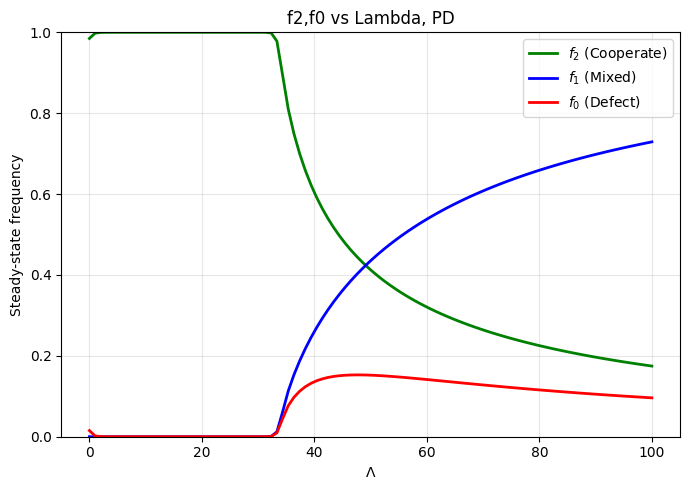

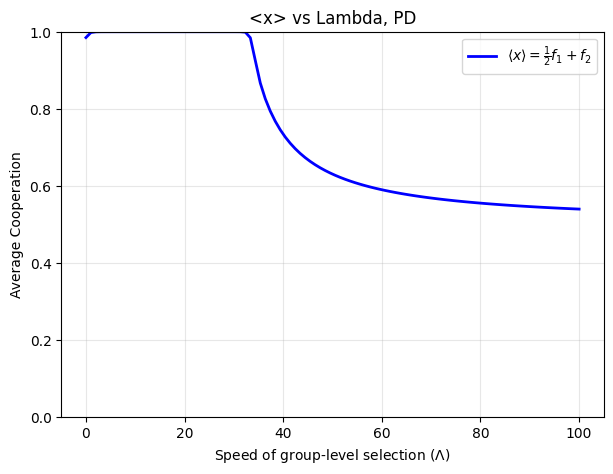

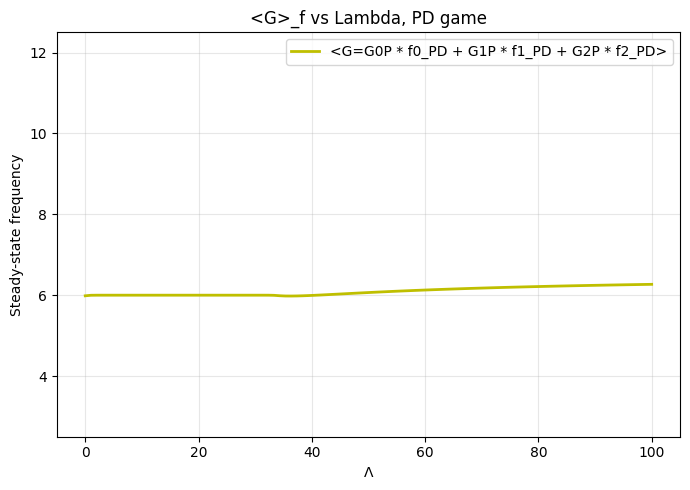

In [9]:
# Fraction of f2, f0; <x>; <G>_f vs different Lambda
import numpy as np
import matplotlib.pyplot as plt

# HD_params = dict(R=6, S=5, T=12, P=3)
# PD_params = dict(R=0.8, S=0.3, T=1, P=0.5)
PD_params = dict(R=6, S=3, T=12, P=5)

w_I, w_G = 0.01, 0.01

Lambda_list = np.linspace(0, 100, 100)
t_end = 200
dt = 0.01

def make_TN_system(R, S, T, P, w_I, w_G, Lambda):
    G_1 = (T + S) / 2.0

    def TN(t, f):
        f0, f1, f2 = f

        term0 = f0 * np.exp(w_G * P)
        term1 = f1 * np.exp(w_G * G_1)
        term2 = f2 * np.exp(w_G * R)
        D = term0 + term1 + term2
        if D == 0:
            D = 1e-10

        df0 = (0.5 * (np.exp(w_I * T) / (np.exp(w_I * T) + np.exp(w_I * S))) * f1
               + Lambda * f0 * ((np.exp(w_G * P) / D) - 1))

        df1 = (-0.5 * f1
               + Lambda * f1 * ((np.exp(w_G * G_1) / D) - 1))

        df2 = (0.5 * (np.exp(w_I * S) / (np.exp(w_I * T) + np.exp(w_I * S))) * f1
               + Lambda * f2 * ((np.exp(w_G * R) / D) - 1))

        return np.array([df0, df1, df2])
    return TN

# def make_TN_system(R, S, T, P, w_I, w_G, Lambda): #linear
#     G_1 = (T + S) / 2.0

#     def TN(t, f):
#         f0, f1, f2 = f

#         G_avg = P * f0 + ((T + S) / 2) * f1 + R * f2
#         df0 = (1 + w_I * T) * f1 + Lambda * w_G * f0 * (P - G_avg)

#         df1 = -(2 + w_I * (T + S)) * f1 + Lambda * w_G * f1 * (((T + S) / 2) - G_avg)

#         df2 = (1 + w_I * S) * f1 + Lambda * w_G * f2 * (R - G_avg)

#         return np.array([df0, df1, df2])
#     return TN

def rk4_step(f, t, y, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + dt * (k1 + 2*k2 + 2*k3 + k4) / 6


def solve_to_steady(system, y0):
    y = y0.copy()
    t = 0.0
    while t < t_end:
        y = rk4_step(system, t, y, dt)
        s = y.sum()
        if s > 0:
            y /= s

        t += dt
    return y


def continuation_independent(params, Lambda_list):
    f0_vals = []
    f1_vals = []
    f2_vals = []
    for Lam in Lambda_list:
        system = make_TN_system(**params, w_I=w_I, w_G=w_G, Lambda=Lam)
        # y_init = np.array([0.33, 0.33, 0.34])
        y_init = np.array([0.01, 0.01, 0.98])
        # y_init = np.array([0.98, 0.01, 0.01])
        y_steady = solve_to_steady(system, y_init)

        f0_vals.append(y_steady[0])
        f1_vals.append(y_steady[1])
        f2_vals.append(y_steady[2])

    return np.array(f0_vals), np.array(f1_vals), np.array(f2_vals)



# f0_HD, f1_HD, f2_HD = continuation_independent(HD_params, Lambda_list)
f0_PD, f1_PD, f2_PD = continuation_independent(PD_params, Lambda_list)

# threshold = 0.998
# for i in range(len(Lambda_list)-1):
#     if f2_PD[i] > threshold and f2_PD[i+1] <= threshold:
#         L1, L2 = Lambda_list[i], Lambda_list[i+1]
#         f1, f2v = f2_PD[i], f2_PD[i+1]

#         Lambda_star = L1 + (threshold - f1) * (L2 - L1) / (f2v - f1)

#         print("Lambda ≈", Lambda_star)
#         break
threshold = 0.998
start_idx = np.where(Lambda_list >= 10)[0][0]
for i in range(start_idx, len(Lambda_list)):
    if f2_PD[i] < threshold:
        lambda_target = Lambda_list[i]
        break
print(lambda_target)

# avg_coop_HD = 0.5 * f1_HD + f2_HD
avg_coop_PD = 0.5 * f1_PD + f2_PD

# G0H, G1H, G2H = HD_params['P'], (HD_params['T']+HD_params['R']+HD_params['P']+HD_params['S'])/4, HD_params['R']
G0P, G1P, G2P = PD_params['P'], (PD_params['T']+PD_params['R']+PD_params['P']+PD_params['S'])/4, PD_params['R']
# payoff_HD = G0H * f0_HD + G1H * f1_HD + G2H * f2_HD
payoff_PD = G0P * f0_PD + G1P * f1_PD + G2P * f2_PD


# plt.figure(figsize=(7,5))
# plt.plot(Lambda_list, f2_HD, 'g', lw=2, label=r'$f_2$ (Cooperate)')
# plt.plot(Lambda_list, f1_HD, 'b', lw=2, label=r'$f_1$ (Mixed)')
# plt.plot(Lambda_list, f0_HD, 'r', lw=2, label=r'$f_0$ (Defect)')
# plt.xlabel(r'$\Lambda$')
# plt.ylabel('Steady-state frequency')
# plt.title('f2,f0 vs Lambda, HD game')
# plt.ylim(0,1)
# plt.grid(alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(7,5))
# # Plot Average Cooperation
# plt.plot(Lambda_list, avg_coop_HD, 'b', lw=2, label=r'$\langle x \rangle = \frac{1}{2}f_1 + f_2$')
# # Optional: Keep the others faint for reference if you want
# # plt.plot(Lambda_list, f2_PD, 'g--', alpha=0.3, label=r'$f_2$')
# # plt.plot(Lambda_list, f0_PD, 'r--', alpha=0.3, label=r'$f_0$')
# plt.xlabel(r'Speed of group-level selection ($\Lambda$)') # Label from the board
# plt.ylabel('Average Cooperation')
# plt.title('<x> vs Lambda, HD')
# plt.ylim(0,1)
# plt.legend()
# plt.grid(alpha=0.3)
# plt.show()

# plt.figure(figsize=(7,5))
# plt.plot(Lambda_list, payoff_HD, 'y', lw=2, label=r'<G=G0P * f0_HD + G1P * f1_HD + G2P * f2_HD>')
# plt.xlabel(r'$\Lambda$')
# plt.ylabel('Steady-state frequency')
# plt.title('<G>_f vs Lambda, HD game')
# plt.ylim(min(HD_params.values())-0.5, max(HD_params.values())+0.5)
# plt.grid(alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()

print()
plt.figure(figsize=(7,5))
plt.plot(Lambda_list, f2_PD, 'g', lw=2, label=r'$f_2$ (Cooperate)')
plt.plot(Lambda_list, f1_PD, 'b', lw=2, label=r'$f_1$ (Mixed)')
plt.plot(Lambda_list, f0_PD, 'r', lw=2, label=r'$f_0$ (Defect)')
plt.xlabel(r'$\Lambda$')
plt.ylabel('Steady-state frequency')
plt.title('f2,f0 vs Lambda, PD')
plt.ylim(0,1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
# Plot Average Cooperation
plt.plot(Lambda_list, avg_coop_PD, 'b', lw=2, label=r'$\langle x \rangle = \frac{1}{2}f_1 + f_2$')
# Optional: Keep the others faint for reference if you want
# plt.plot(Lambda_list, f2_PD, 'g--', alpha=0.3, label=r'$f_2$')
# plt.plot(Lambda_list, f0_PD, 'r--', alpha=0.3, label=r'$f_0$')
plt.xlabel(r'Speed of group-level selection ($\Lambda$)') # Label from the board
plt.ylabel('Average Cooperation')
plt.title('<x> vs Lambda, PD')
plt.ylim(0,1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7,5))
plt.plot(Lambda_list, payoff_PD, 'y', lw=2, label=r'<G=G0P * f0_PD + G1P * f1_PD + G2P * f2_PD>')
plt.xlabel(r'$\Lambda$')
plt.ylabel('Steady-state frequency')
plt.title('<G>_f vs Lambda, PD game')
plt.ylim(min(PD_params.values())-0.5, max(PD_params.values())+0.5)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()




143.43434343434345



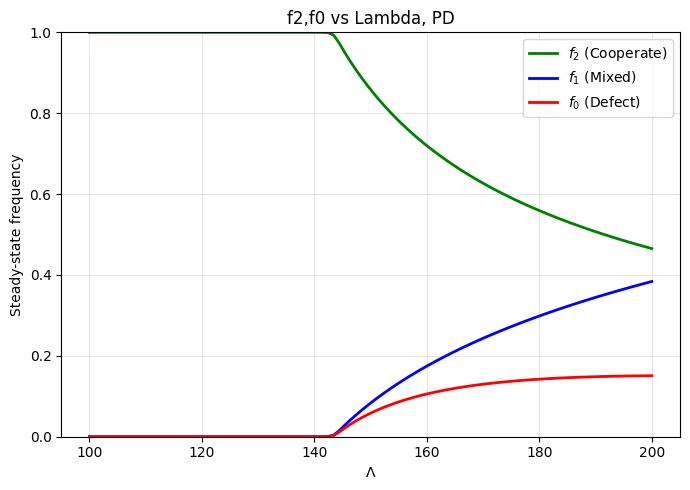

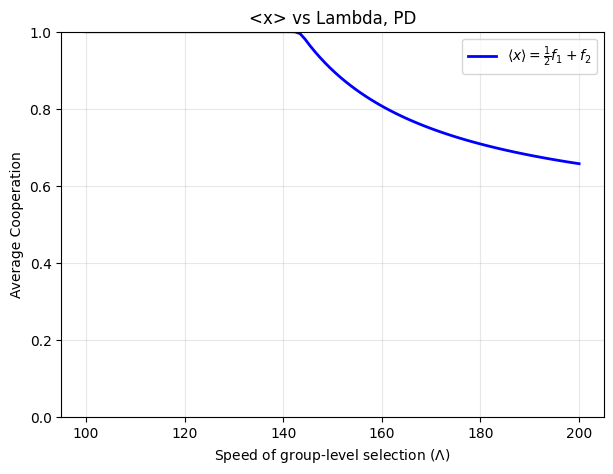

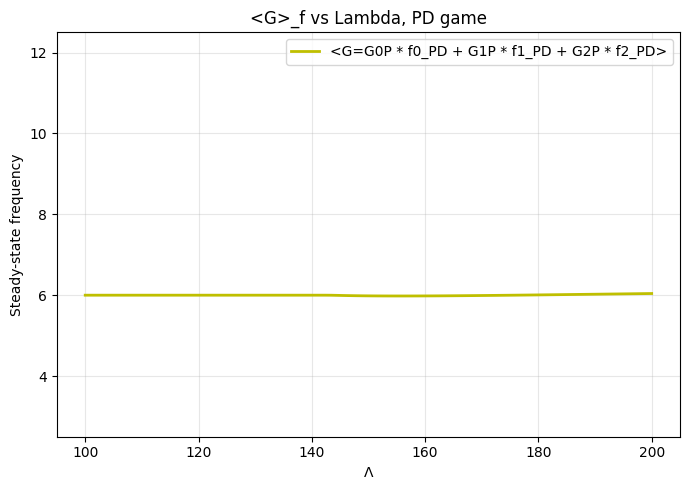

In [10]:
# Fraction of f2, f0; <x>; <G>_f vs different Lambda
import numpy as np
import matplotlib.pyplot as plt

# HD_params = dict(R=6, S=5, T=12, P=3)
# PD_params = dict(R=0.8, S=0.3, T=1, P=0.5)
PD_params = dict(R=6, S=3, T=12, P=5)

w_I, w_G = 0.01, 0.01

Lambda_list = np.linspace(100, 200, 100)
t_end = 200
dt = 0.01

# def make_TN_system(R, S, T, P, w_I, w_G, Lambda):
#     G_1 = (T + S) / 2.0

#     def TN(t, f):
#         f0, f1, f2 = f

#         term0 = f0 * np.exp(w_G * P)
#         term1 = f1 * np.exp(w_G * G_1)
#         term2 = f2 * np.exp(w_G * R)
#         D = term0 + term1 + term2
#         if D == 0:
#             D = 1e-10

#         df0 = (0.5 * (np.exp(w_I * T) / (np.exp(w_I * T) + np.exp(w_I * S))) * f1
#                + Lambda * f0 * ((np.exp(w_G * P) / D) - 1))

#         df1 = (-0.5 * f1
#                + Lambda * f1 * ((np.exp(w_G * G_1) / D) - 1))

#         df2 = (0.5 * (np.exp(w_I * S) / (np.exp(w_I * T) + np.exp(w_I * S))) * f1
#                + Lambda * f2 * ((np.exp(w_G * R) / D) - 1))

#         return np.array([df0, df1, df2])
#     return TN

def make_TN_system(R, S, T, P, w_I, w_G, Lambda): #linear
    G_1 = (T + S) / 2.0

    def TN(t, f):
        f0, f1, f2 = f

        G_avg = P * f0 + ((T + S) / 2) * f1 + R * f2
        df0 = (1 + w_I * T) * f1 + Lambda * w_G * f0 * (P - G_avg)

        df1 = -(2 + w_I * (T + S)) * f1 + Lambda * w_G * f1 * (((T + S) / 2) - G_avg)

        df2 = (1 + w_I * S) * f1 + Lambda * w_G * f2 * (R - G_avg)

        return np.array([df0, df1, df2])
    return TN

def rk4_step(f, t, y, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + dt * (k1 + 2*k2 + 2*k3 + k4) / 6


def solve_to_steady(system, y0):
    y = y0.copy()
    t = 0.0
    while t < t_end:
        y = rk4_step(system, t, y, dt)
        s = y.sum()
        if s > 0:
            y /= s

        t += dt
    return y


def continuation_independent(params, Lambda_list):
    f0_vals = []
    f1_vals = []
    f2_vals = []
    for Lam in Lambda_list:
        system = make_TN_system(**params, w_I=w_I, w_G=w_G, Lambda=Lam)
        # y_init = np.array([0.33, 0.33, 0.34])
        y_init = np.array([0.01, 0.01, 0.98])
        # y_init = np.array([0.98, 0.01, 0.01])
        y_steady = solve_to_steady(system, y_init)

        f0_vals.append(y_steady[0])
        f1_vals.append(y_steady[1])
        f2_vals.append(y_steady[2])

    return np.array(f0_vals), np.array(f1_vals), np.array(f2_vals)



# f0_HD, f1_HD, f2_HD = continuation_independent(HD_params, Lambda_list)
f0_PD, f1_PD, f2_PD = continuation_independent(PD_params, Lambda_list)

# threshold = 0.998
# for i in range(len(Lambda_list)-1):
#     if f2_PD[i] > threshold and f2_PD[i+1] <= threshold:
#         L1, L2 = Lambda_list[i], Lambda_list[i+1]
#         f1, f2v = f2_PD[i], f2_PD[i+1]

#         Lambda_star = L1 + (threshold - f1) * (L2 - L1) / (f2v - f1)

#         print("Lambda ≈", Lambda_star)
#         break
threshold = 0.998
start_idx = np.where(Lambda_list >= 10)[0][0]
for i in range(start_idx, len(Lambda_list)):
    if f2_PD[i] < threshold:
        lambda_target = Lambda_list[i]
        break
print(lambda_target)

# avg_coop_HD = 0.5 * f1_HD + f2_HD
avg_coop_PD = 0.5 * f1_PD + f2_PD

# G0H, G1H, G2H = HD_params['P'], (HD_params['T']+HD_params['R']+HD_params['P']+HD_params['S'])/4, HD_params['R']
G0P, G1P, G2P = PD_params['P'], (PD_params['T']+PD_params['R']+PD_params['P']+PD_params['S'])/4, PD_params['R']
# payoff_HD = G0H * f0_HD + G1H * f1_HD + G2H * f2_HD
payoff_PD = G0P * f0_PD + G1P * f1_PD + G2P * f2_PD


# plt.figure(figsize=(7,5))
# plt.plot(Lambda_list, f2_HD, 'g', lw=2, label=r'$f_2$ (Cooperate)')
# plt.plot(Lambda_list, f1_HD, 'b', lw=2, label=r'$f_1$ (Mixed)')
# plt.plot(Lambda_list, f0_HD, 'r', lw=2, label=r'$f_0$ (Defect)')
# plt.xlabel(r'$\Lambda$')
# plt.ylabel('Steady-state frequency')
# plt.title('f2,f0 vs Lambda, HD game')
# plt.ylim(0,1)
# plt.grid(alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(7,5))
# # Plot Average Cooperation
# plt.plot(Lambda_list, avg_coop_HD, 'b', lw=2, label=r'$\langle x \rangle = \frac{1}{2}f_1 + f_2$')
# # Optional: Keep the others faint for reference if you want
# # plt.plot(Lambda_list, f2_PD, 'g--', alpha=0.3, label=r'$f_2$')
# # plt.plot(Lambda_list, f0_PD, 'r--', alpha=0.3, label=r'$f_0$')
# plt.xlabel(r'Speed of group-level selection ($\Lambda$)') # Label from the board
# plt.ylabel('Average Cooperation')
# plt.title('<x> vs Lambda, HD')
# plt.ylim(0,1)
# plt.legend()
# plt.grid(alpha=0.3)
# plt.show()

# plt.figure(figsize=(7,5))
# plt.plot(Lambda_list, payoff_HD, 'y', lw=2, label=r'<G=G0P * f0_HD + G1P * f1_HD + G2P * f2_HD>')
# plt.xlabel(r'$\Lambda$')
# plt.ylabel('Steady-state frequency')
# plt.title('<G>_f vs Lambda, HD game')
# plt.ylim(min(HD_params.values())-0.5, max(HD_params.values())+0.5)
# plt.grid(alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()

print()
plt.figure(figsize=(7,5))
plt.plot(Lambda_list, f2_PD, 'g', lw=2, label=r'$f_2$ (Cooperate)')
plt.plot(Lambda_list, f1_PD, 'b', lw=2, label=r'$f_1$ (Mixed)')
plt.plot(Lambda_list, f0_PD, 'r', lw=2, label=r'$f_0$ (Defect)')
plt.xlabel(r'$\Lambda$')
plt.ylabel('Steady-state frequency')
plt.title('f2,f0 vs Lambda, PD')
plt.ylim(0,1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
# Plot Average Cooperation
plt.plot(Lambda_list, avg_coop_PD, 'b', lw=2, label=r'$\langle x \rangle = \frac{1}{2}f_1 + f_2$')
# Optional: Keep the others faint for reference if you want
# plt.plot(Lambda_list, f2_PD, 'g--', alpha=0.3, label=r'$f_2$')
# plt.plot(Lambda_list, f0_PD, 'r--', alpha=0.3, label=r'$f_0$')
plt.xlabel(r'Speed of group-level selection ($\Lambda$)') # Label from the board
plt.ylabel('Average Cooperation')
plt.title('<x> vs Lambda, PD')
plt.ylim(0,1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7,5))
plt.plot(Lambda_list, payoff_PD, 'y', lw=2, label=r'<G=G0P * f0_PD + G1P * f1_PD + G2P * f2_PD>')
plt.xlabel(r'$\Lambda$')
plt.ylabel('Steady-state frequency')
plt.title('<G>_f vs Lambda, PD game')
plt.ylim(min(PD_params.values())-0.5, max(PD_params.values())+0.5)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()




In [5]:

R = 6
S = 3
T = 12
P = 5
w_I, w_G = 0.01, 0.01
a = 2 * (2 + w_I * (T+S))
b = w_G * (T+S-2*R)
c = a/b
print(c) # linear

d = np.exp(w_G * R)
e = 2 * (np.exp(w_G * ((T+S)/2))-np.exp(w_G * R))
print(d/e) #Traulsen

143.33333333333334
33.08395833098966
